# Pairs trading on the day lake — I. Universe, adjustment and survivorship

## `pairs_trading_06_daily_lake.ipynb`

Notebooks 01–05 ran the pipeline on daily closes downloaded for the **current** members of the S&P 500
and Nasdaq-100. That is convenient and quietly wrong in three ways: the member list is the list of
survivors, the downloaded prices are dividend-adjusted with hindsight, and a single traded pair is not a
strategy. This series rebuilds the daily study on a local Polygon-derived **day lake** that fixes all
three, and notebooks 09–11 then ask the same questions of minute bars.

| notebook | question |
|---|---|
| **06 (this one)** | What is in the day lake, which price series is safe to trade on, how is a point-in-time universe built, and how large is the survivorship bias in the old approach? |
| 07 | Does cointegration exist among liquid US equities at all? Twenty years of screening, with the multiple-testing arithmetic taken seriously |
| 08 | The twenty-year portfolio backtest: three selection rules, real costs, dividends, regimes, and what the survivorship bias was worth |

Everything runs on the package API; `pairs.market_data.daily_bars` was added for this series.

**Caching.** Intermediate frames go to `notebooks/cache/` (gitignored). A cold run takes about two
minutes. The lake is read-only; set `DAY_LAKE` if it lives somewhere other than
`~/local/parquet_lake/day_adj`.

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, time, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

import pairs
from pairs import (load_universe, load_daily_bars, detect_day_lake_layout, recover_dividends,
                   liquidity_screen)

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"                   # every symbol that ever traded
INDEX_ROOT  = LAKE / "spx_ndx_combined_adjusted"      # today's index members only
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END = "2004-01-01", "2025-08-13"               # the lake begins 2003-09 and ends 2025-08-13
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
LAKE_LABEL = f"~/{LAKE.relative_to(Path.home())}" if LAKE.is_relative_to(Path.home()) else str(LAKE)
print("pairs", pairs.__version__, "| lake:", LAKE_LABEL, "| layouts:",
      detect_day_lake_layout(INDEX_ROOT), "/", detect_day_lake_layout(MARKET_ROOT))

pairs 0.1.0 | lake: ~/local/parquet_lake/day_adj | layouts: ticker / market


## 1. The day lake

Daily aggregates from 2003-09-10 to 2025-08-13 in the same two layouts as the minute lake, but with
monthly files instead of daily ones:

| layout | path | contents |
|---|---|---|
| **market** | `all_adjusted/<YYYY>/<MM>.parquet` | every symbol that traded that month — 33,833 over the whole lake, including everything since delisted |
| **ticker** | `spx_ndx_combined_adjusted/<TICKER>/<YYYY>/<MM>.parquet` | only the 517 current S&P 500 + Nasdaq-100 members |

The whole market layout is 264 files and 46 million rows, and reads in about a second — so unlike the
minute lake, the entire daily history fits comfortably in memory and no sidecar is needed.

A `_event_summary.csv` sits beside the market layout with one row per instrument: its FIGI, the
cumulative split ratio, the number of dividend events and the last date of each.

In [2]:
sample = MARKET_ROOT / "2024" / "06.parquet"
pf = pq.ParquetFile(sample)
print(f"{sample.relative_to(LAKE)}: {pf.metadata.num_rows:,} rows, {pf.metadata.num_row_groups} row group(s)")
print(pf.schema_arrow.to_string(show_schema_metadata=False))

events = pd.read_csv(MARKET_ROOT / "_event_summary.csv")
print(f"\n_event_summary.csv: {len(events):,} instruments")
display(events[events["ticker"].isin(["AAPL", "NVDA", "TROW", "GE"])]
        [["ticker", "id", "split_events_aligned", "split_cum_ratio", "dividend_event_days",
          "dividend_total_cash", "last_dividend_raw_date", "last_datetime"]].to_string(index=False))

all_adjusted/2024/06.parquet: 200,364 rows, 1 row group(s)
datetime: timestamp[ns]
ticker: large_string
id: large_string
close: double
volume: int64
close_split: double
volume_split: double
close_tr: double
split_price_factor: double
tr_price_factor: double
open_split: double
high_split: double
low_split: double
open_tr: double
high_tr: double
low_tr: double

_event_summary.csv: 30,792 instruments


'ticker           id  split_events_aligned  split_cum_ratio  dividend_event_days  dividend_total_cash last_dividend_raw_date       last_datetime\n  AAPL BBG000B9XRY4                     5       224.000000                   57               45.120             2026-08-10 2025-08-13 04:00:00\n    GE BBG000BK6MB5                     3         0.200637                   91               16.870             2026-07-06 2025-08-13 04:00:00\n  NVDA BBG000BBJQV0                     4       120.000000                   56                5.405             2026-09-10 2025-08-13 04:00:00\n  TROW BBG000BVMPN3                     1         2.000000                   95               62.260             2026-09-15 2025-08-13 04:00:00'

## 2. Three price series, and a look-ahead hiding in one of them

Every row carries the same bar three ways:

* `close` — raw, as printed. Discontinuous across splits: NVDA drops tenfold on 2024-06-10.
* `close_split` — adjusted for splits only. Splits are mechanical and known on the day, so this is the
  series a trader would actually have seen, rebased.
* `close_tr` — adjusted for splits **and** dividends, back-adjusted so the factor equals 1.0 on the
  lake's **last** date.

That last definition is the problem. The factor at any historical date is built from every dividend paid
*after* that date. AAPL's factor is 0.84 in 2003 and 1.0 in 2025: the 2003 "price" has been marked down
by 22 years of dividends that had not been announced yet. Using `close_tr` as the price a strategy trades
on imports that hindsight into every level-based signal — and a pairs spread is entirely level-based.

The fix is not to throw the dividends away. The factor steps only on ex-dividend dates, and the step size
is exactly $1 - D/P_\text{prev}$, so the dividend stream can be **recovered** from it and accrued as a
cash flow at the moment it was actually paid. `recover_dividends` does this and `load_daily_bars` exposes
it as a `dividend` column.

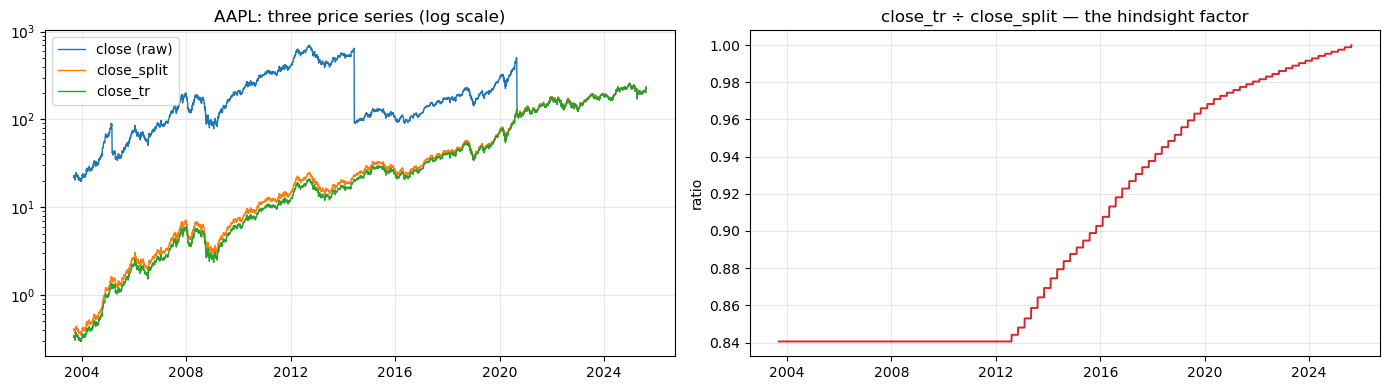

AAPL: 53 ex-dividend dates recovered from the factor; last four {'2024-11-08': 0.25, '2025-02-10': 0.25, '2025-05-12': 0.26, '2025-08-11': 0.26}
the tr factor marks the 2003 price down by 15.9%, and by 11.2% as late as 2015
recovered dividend yield by year: {2019: 0.0146, 2020: 0.0085, 2021: 0.0061, 2022: 0.0059, 2023: 0.0055, 2024: 0.0048}


In [3]:
aapl = load_daily_bars(["AAPL"], "2003-01-01", END, MARKET_ROOT, with_dividends=True).loc["AAPL"]
raw  = load_daily_bars(["AAPL"], "2003-01-01", END, MARKET_ROOT, price="raw")["close"].droplevel("ticker")
tr   = load_daily_bars(["AAPL"], "2003-01-01", END, MARKET_ROOT, price="tr")["close"].droplevel("ticker")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].semilogy(raw.index, raw, lw=1, label="close (raw)")
ax[0].semilogy(aapl.index, aapl["close"], lw=1, label="close_split")
ax[0].semilogy(tr.index, tr, lw=1, label="close_tr")
ax[0].set_title("AAPL: three price series (log scale)"); ax[0].legend()
ax[1].plot(aapl.index, tr / aapl["close"], lw=1.4, color="tab:red")
ax[1].set_title("close_tr ÷ close_split — the hindsight factor"); ax[1].set_ylabel("ratio")
plt.tight_layout(); plt.show()

paid = aapl[aapl["dividend"] > 0]
print(f"AAPL: {len(paid)} ex-dividend dates recovered from the factor; last four "
      f"{ {str(d.date()): round(v, 3) for d, v in paid['dividend'].tail(4).items()} }")
print(f"the tr factor marks the 2003 price down by {1 - float(tr.iloc[0] / aapl['close'].iloc[0]):.1%}, "
      f"and by {1 - float(tr.loc['2015-01-02'] / aapl['close'].loc['2015-01-02']):.1%} as late as 2015")
yield_by_year = (aapl["dividend"].groupby(aapl.index.year).sum() / aapl["close"].groupby(aapl.index.year).mean())
print("recovered dividend yield by year:", yield_by_year.loc[2019:2024].round(4).to_dict())

**Rule adopted for the rest of the series:** trade on `close_split`, and accrue the recovered
`dividend` as a cash flow on the ex-date. Notebook 08 reports the backtest with and without it.

## 3. Tickers are reused, and it splices companies together

The market layout contains every symbol that ever traded, and exchanges reissue symbols. "TROW" in
December 2003 is both T. Rowe Price and a near-untraded namesake; "DOC" is both Physicians Realty and a
company that last traded in 2007. Each row carries an `id` (a FIGI, or a `NOFIGI__`/`CIK__` placeholder),
which is the real instrument key.

`load_daily_bars` resolves each ticker to the single instrument with the most dollar volume in the
window requested and reports what it dropped. Without that step a price series can jump between two
different companies mid-sample — which for a cointegration screen is a structural break manufactured
out of nothing.

In [4]:
f_bars, f_clash = CACHE / "day_market_bars.parquet", CACHE / "day_ticker_collisions.parquet"
if f_bars.exists() and f_clash.exists():
    bars = pd.read_parquet(f_bars)
    collisions = pd.read_parquet(f_clash)
else:
    t0 = time.time()
    bars = load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True)
    collisions = pd.DataFrame(bars.attrs["ticker_collisions"])
    print(f"whole market {START} → {END}: {time.time() - t0:.0f}s")
    bars.to_parquet(f_bars); collisions.to_parquet(f_clash)
print(f"{len(bars):,} rows | {bars.index.get_level_values('ticker').nunique():,} tickers | "
      f"{bars.index.get_level_values('datetime').nunique():,} sessions")
print(f"tickers used by more than one instrument: {collisions['ticker'].nunique():,} "
      f"({collisions['ticker'].nunique() / bars.index.get_level_values('ticker').nunique():.0%} of the lake)")
display(collisions.nlargest(6, "dropped_dollar_volume"))

43,764,473 rows | 33,316 tickers | 5,438 sessions


tickers used by more than one instrument: 3,452 (10% of the lake)


,ticker,kept,dropped,dropped_dollar_volume
4371,VXX,NOFIGI__VXX#SEG0,BBG00JQ5JWB5,8.958253e+11
3431,QQQ,BBG000BSWKH7,NOFIGI__QQQ#SEG0,8.209238e+11
1169,DELL,NOFIGI__DELL#SEG0,BBG00DW3SZS1,6.574475e+11
139,AGN,CIK__0001578845,NOFIGI__AGN#SEG0,4.708120e+11
3519,RIO,BBG000FD28T3,NOFIGI__RIO#SEG0,4.690944e+11
1838,GM,BBG000NDYB67,NOFIGI__GM#SEG0,4.322787e+11


## 4. Three more things a curated index list would have hidden

Ticker reuse is not the only hazard of working from the whole market. Three more surface immediately,
and each one, left alone, ends up manufacturing "cointegrated" pairs.

**Exchange test symbols.** NASDAQ publishes a family of test tickers — `ZVZZT`, `ZWZZT`, `ZXZZT` and
siblings — that quote and print like real securities so that member firms can exercise their systems.
They are in the lake, they pass a liquidity filter, and their prices are nonsense.

**Corporate actions the adjustment missed.** A one-day move of several hundred percent is not a price;
it is a reverse split the factor file did not catch. Left in, it is a structural break in the middle of
a formation window.

**The split-adjustment price trap.** This one is the subtlest and it reverses the meaning of a price
filter. Split adjustment is *backward*-looking: a stock that later split is marked down in the past, and
a stock that later reverse-split is marked *up*. So a "\$5 minimum price" applied to the adjusted series
excludes the wrong names in both directions.

In [5]:
import re
all_tickers = bars.index.get_level_values("ticker").unique()
TEST_SYMBOLS = sorted(t for t in all_tickers if re.fullmatch(r"Z[A-Z]ZZT", str(t)))
zv = bars.loc["ZVZZT", "close"] if "ZVZZT" in set(all_tickers) else None
print(f"exchange test symbols present: {TEST_SYMBOLS}")
if zv is not None:
    print(f"ZVZZT: {len(zv):,} sessions, median ${zv.median():.2f}, range ${zv.min():.2f} – ${zv.max():,.0f}")

px_all = bars["close"].unstack("ticker")
ret_all = px_all / px_all.shift(1) - 1.0
extreme = ret_all.abs() > 1.0
per_ticker = extreme.sum().sort_values(ascending=False)
print(f"tickers with a one-day move over 100%: {int((per_ticker > 0).sum()):,}; "
      f"the worst are {per_ticker.head(4).to_dict()}")
worst = ret_all.max().sort_values(ascending=False).head(5)
print("largest single-day returns in the lake:", {t: f"{v:,.0f}x" for t, v in worst.items()})

exchange test symbols present: ['ZAZZT', 'ZBZZT', 'ZCZZT', 'ZDZZT', 'ZEZZT', 'ZFZZT', 'ZJZZT', 'ZOZZT', 'ZRZZT', 'ZUZZT', 'ZVZZT', 'ZWZZT', 'ZXZZT']
ZVZZT: 5,429 sessions, median $17.21, range $0.00 – $200,000


tickers with a one-day move over 100%: 3,456; the worst are {'ZXZZT': 988, 'ZVZZT': 923, 'ZWZZT': 742, 'ZJZZT': 46}


largest single-day returns in the lake: {'ZXZZT': '1,999,999,899x', 'ZWZZT': '999,999,949x', 'AAZST': '79,999,999x', 'ZJZZT': '19,999,999x', 'ZVZZT': '1,000,499x'}


In [6]:
# the split-adjustment trap, in the window that produced the artifacts of an earlier draft of this series
probe = load_daily_bars(["AAPL", "SIRI", "C", "UNG"], "2007-07-01", "2009-07-01", MARKET_ROOT)
trap = pd.DataFrame({
    "median raw close": probe.groupby(level="ticker")["raw_close"].median(),
    "median split-adjusted close": probe.groupby(level="ticker")["close"].median(),
})
trap["later split/reverse-split"] = ["7:1 then 4:1", "1:10 reverse", "1:10 reverse", "repeated reverses"]
trap["passes a $5 gate on raw"] = trap["median raw close"] >= 5
trap["passes a $5 gate on adjusted"] = trap["median split-adjusted close"] >= 5
display(trap.round(2))
print("A $5 gate on the adjusted price throws out Apple at $136 and keeps Sirius at $2 — exactly backwards.")

,median raw close,median split-adjusted close,later split/reverse-split,passes a $5 gate on raw,passes a $5 gate on adjusted
ticker,,,,,
AAPL,136.22,4.86,7:1 then 4:1,True,False
C,19.78,197.80,1:10 reverse,True,True
SIRI,2.13,21.30,1:10 reverse,False,True
UNG,37.14,4753.92,repeated reverses,True,True


A $5 gate on the adjusted price throws out Apple at $136 and keeps Sirius at $2 — exactly backwards.


`liquidity_screen` therefore applies its price gate to `raw_close`, caps the one-day move, and accepts an
explicit exclusion list. In an earlier draft of this series, gating on the adjusted price made Sirius XM
the single biggest hub in the 2008 cointegration screen, with nine of the fifteen strongest results in
twenty years. None of them were real.

## 5. A point-in-time universe

At each formation date the universe is rebuilt from what was tradeable **then**. Over the trailing
two-year window a ticker qualifies if it traded on at least 99% of sessions, its median **unadjusted**
close was at least \$5, its median dollar volume was at least \$20M, its annualised volatility was at
least 15%, its largest one-day move was under 100%, and it is not an exchange test symbol.

The volatility floor is the one rule that needs its own argument; §6 makes it.

Because this is derived from the market layout it includes companies that were liquid then and are gone
now — which is the whole point.

39 semi-annual formation dates, 2006-06-30 → 2025-07-01


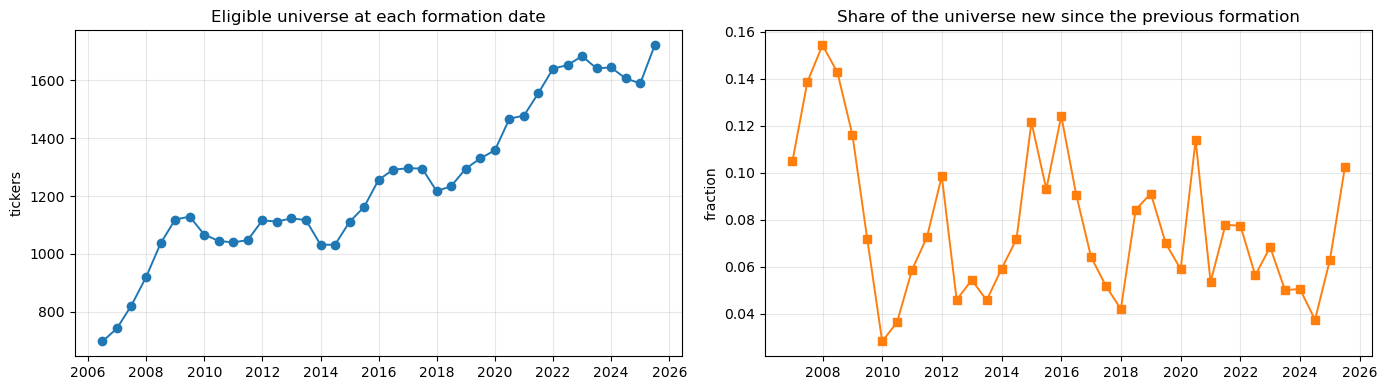

universe size: 698 → 1721 (median 1217); median semi-annual turnover 7.1%
of the 698 names liquid in 2006-06-30, 337 (48%) are still liquid in 2025-07-01


In [7]:
FORM_YEARS, MIN_PRICE, MIN_DV, MIN_VOL, MAX_ABS_RET, TOP_N = 2, 5.0, 20e6, 0.15, 1.0, 300
sessions = pd.DatetimeIndex(sorted(bars.index.get_level_values("datetime").unique()))

def formation_dates(first="2006-06-30", freq="6MS"):
    anchors = pd.date_range(first, sessions[-1], freq=freq)
    return pd.DatetimeIndex(sorted({sessions[sessions <= a][-1] for a in anchors if (sessions <= a).any()}))

def window_bars(end, years=FORM_YEARS):
    start = end - pd.DateOffset(years=years)
    lvl = bars.index.get_level_values("datetime")
    return bars[(lvl > start) & (lvl <= end)]

def universe_at(end, top_n=TOP_N, min_ann_vol=MIN_VOL, max_abs_return=MAX_ABS_RET):
    return liquidity_screen(window_bars(end), min_price=MIN_PRICE, min_dollar_volume=MIN_DV,
                            min_ann_vol=min_ann_vol, max_abs_return=max_abs_return,
                            exclude=TEST_SYMBOLS, top_n=top_n)

FORMATIONS = formation_dates()
print(f"{len(FORMATIONS)} semi-annual formation dates, {FORMATIONS[0].date()} → {FORMATIONS[-1].date()}")
f_univ = CACHE / "day_universe.parquet"
if f_univ.exists():
    univ = pd.read_parquet(f_univ)
else:
    rows = []
    for d in FORMATIONS:
        st = universe_at(d, top_n=None)
        rows.append(pd.DataFrame({"formation": d, "ticker": st.index, "eligible": st["eligible"].to_numpy(),
                                  "median_dollar_volume": st["median_dollar_volume"].to_numpy(),
                                  "ann_vol": st["ann_vol"].to_numpy()}))
    univ = pd.concat(rows, ignore_index=True)
    univ.to_parquet(f_univ)
elig = {d: set(g[g["eligible"]]["ticker"]) for d, g in univ.groupby("formation")}
counts = pd.Series({d: len(v) for d, v in elig.items()}).sort_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(counts.index, counts.to_numpy(), marker="o", lw=1.4)
ax[0].set_title("Eligible universe at each formation date"); ax[0].set_ylabel("tickers")
ds = sorted(elig)
turnover = [len(elig[b] - elig[a]) / max(len(elig[b]), 1) for a, b in zip(ds, ds[1:])]
ax[1].plot(ds[1:], turnover, marker="s", lw=1.4, color="tab:orange")
ax[1].set_title("Share of the universe new since the previous formation"); ax[1].set_ylabel("fraction")
plt.tight_layout(); plt.show()
print(f"universe size: {counts.min()} → {counts.max()} (median {int(counts.median())}); "
      f"median semi-annual turnover {np.median(turnover):.1%}")
survivors = len(elig[ds[0]] & elig[ds[-1]])
print(f"of the {len(elig[ds[0]])} names liquid in {ds[0].date()}, {survivors} ({survivors/len(elig[ds[0]]):.0%}) "
      f"are still liquid in {ds[-1].date()}")

## 6. Why the volatility floor is not optional

Rank a liquid universe by dollar volume and the top of the list is not companies — it is ETFs, and near
the very top sit the money-market and ultra-short bond funds: BIL, SGOV, SHV, BOXX. Their prices move a
fraction of a percent a year. A cointegration test asks whether some linear combination of two series is
stationary, and a series that is *already* nearly constant makes that true against almost anything.

Screening the 2024 universe without the floor, BIL alone passes the dual gate with 266 partners and SGOV
with 85. Those are not trades; they are an artifact of testing a stationarity hypothesis against a series
that is stationary by construction. The floor removes them and costs nothing else.

In [8]:
d = FORMATIONS[-1]
st_all = universe_at(d, top_n=None, min_ann_vol=0.0)
st_flr = universe_at(d, top_n=None)
naive_top = st_all[st_all["eligible"]].nlargest(18, "median_dollar_volume")
print(f"formation {d.date()}: eligible without the volatility floor {int(st_all['eligible'].sum()):,}, "
      f"with it {int(st_flr['eligible'].sum()):,}")
display(naive_top[["median_dollar_volume", "ann_vol"]]
        .assign(**{"$M / day": (naive_top["median_dollar_volume"] / 1e6).round(0),
                   "kept by the floor": naive_top.index.isin(st_flr[st_flr["eligible"]].index)})
        .drop(columns=["median_dollar_volume"]).round(3))
lowest = st_all[st_all["eligible"]].nsmallest(10, "ann_vol")
print("lowest-volatility names a pure liquidity screen would admit:",
      {t: round(v, 4) for t, v in lowest["ann_vol"].items()})

formation 2025-07-01: eligible without the volatility floor 1,860, with it 1,721


,ann_vol,$M / day,kept by the floor
ticker,,,
SPY,0.165,31812.0,True
NVDA,0.516,30466.0,True
TSLA,0.630,25421.0,True
QQQ,0.211,17805.0,True
AAPL,0.273,10032.0,True
MSFT,0.229,7985.0,True
AMZN,0.313,7013.0,True
META,0.360,6749.0,True
AMD,0.494,5935.0,True


lowest-volatility names a pure liquidity screen would admit: {'BOXX': 0.0044, 'JMST': 0.0121, 'SGOV': 0.0136, 'TBIL': 0.0138, 'SHV': 0.0138, 'BIL': 0.0139, 'BILS': 0.0139, 'FTSM': 0.014, 'TFLO': 0.0143, 'USFR': 0.0144}


## 7. Survivorship bias, measured

The packaged `spx_ndx_combined` list is today's membership; notebooks 01–05 applied it to history. Two
questions follow: how much of that list even existed twenty years ago, and how much does restricting to
it flatter a backtest before any strategy is applied?

Both universes below are held to identical rules — equal weight, semi-annual rebalance, total return with
the recovered dividends, the same price basis and the same eligibility gates. The only difference is
whether a name had to be in *today's* index to be held. Returns are winsorised at ±100% a day as a last
data-quality guard, and the number of observations that touches is reported.

in 2006-06-30 only 33% of the liquid universe is in today's index list; by 2025-07-01 it is 29%


daily returns winsorised at ±100%: 9,544 observations of 42,727,422 (0.0223%)


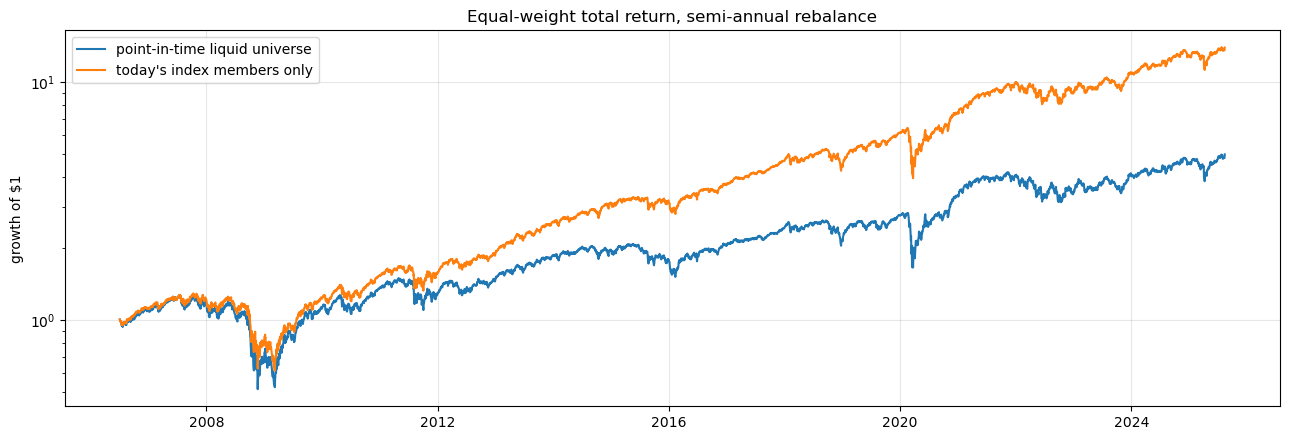

,CAGR,ann vol,Sharpe,max drawdown
point-in-time,0.088,0.230,0.479,-0.597
today's members,0.148,0.212,0.756,-0.525


restricting to today's index members adds +6.05% a year and +0.28 of Sharpe, before any strategy is applied


In [9]:
members = set(load_universe("spx_ndx_combined"))
cov = pd.DataFrame({"eligible": {d: len(v) for d, v in elig.items()},
                    "of which in today's list": {d: len(v & members) for d, v in elig.items()}}).sort_index()
cov["share"] = cov["of which in today's list"] / cov["eligible"]
print(f"in {cov.index[0].date()} only {cov['share'].iloc[0]:.0%} of the liquid universe is in today's "
      f"index list; by {cov.index[-1].date()} it is {cov['share'].iloc[-1]:.0%}")

px = bars["close"].unstack("ticker")
div = bars["dividend"].unstack("ticker").reindex_like(px).fillna(0.0)
ret = (px + div) / px.shift(1) - 1.0
clipped = int((ret.abs() > 1.0).sum().sum())
ret = ret.clip(-1.0, 1.0)
print(f"daily returns winsorised at ±100%: {clipped:,} observations of {int(ret.notna().sum().sum()):,} "
      f"({clipped / ret.notna().sum().sum():.4%})")

def equal_weight_curve(selector):
    parts, ds_ = [], sorted(elig)
    for d, nxt in zip(ds_, list(ds_[1:]) + [sessions[-1]]):
        names = sorted(selector(d) & set(ret.columns))
        if not names:
            continue
        w = ret.loc[(ret.index > d) & (ret.index <= nxt), names]
        parts.append(w.mean(axis=1))
    return (1 + pd.concat(parts)).cumprod()

curve_pit = equal_weight_curve(lambda d: elig[d])
curve_mem = equal_weight_curve(lambda d: elig[d] & members)

def stats(c):
    r = c.pct_change().dropna()
    return {"CAGR": c.iloc[-1] ** (252 / len(c)) - 1, "ann vol": r.std() * np.sqrt(252),
            "Sharpe": r.mean() / r.std() * np.sqrt(252), "max drawdown": float((c / c.cummax() - 1).min())}

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.semilogy(curve_pit.index, curve_pit, lw=1.5, label="point-in-time liquid universe")
ax.semilogy(curve_mem.index, curve_mem, lw=1.5, label="today's index members only")
ax.set_title("Equal-weight total return, semi-annual rebalance"); ax.set_ylabel("growth of $1"); ax.legend()
plt.tight_layout(); plt.show()
tab = pd.DataFrame({"point-in-time": stats(curve_pit), "today's members": stats(curve_mem)}).T
display(tab.round(3))
pit, mem = tab.loc["point-in-time"], tab.loc["today's members"]
print(f"restricting to today's index members adds {mem['CAGR'] - pit['CAGR']:+.2%} a year and "
      f"{mem['Sharpe'] - pit['Sharpe']:+.2f} of Sharpe, before any strategy is applied")

## 8. What this fixes

Five defects in how notebooks 01–05 read their data, each now measured rather than assumed.

* **Dividend look-ahead.** `close_tr` marks the 2003 Apple price down by 16%, and the 2015 price by 11%,
  using dividends that had not been announced. The fix costs nothing: trade `close_split` and accrue the
  dividend recovered from the factor steps at its ex-date.
* **Ticker reuse.** 3,452 tickers — 10% of the lake — name more than one instrument over the sample.
  Left unresolved, a price series can jump between two companies mid-window, which is a structural break
  invented out of nothing.
* **Exchange test symbols.** Thirteen of them are in the lake, and they produce the four largest one-day
  returns in twenty years — up to two billion times. `ZVZZT` has a \$17 median price and passes a naive
  liquidity screen comfortably.
* **The split-adjustment price trap.** A \$5 minimum price on the adjusted series drops 2008 Apple, which
  traded at \$136, and keeps 2008 Sirius, which traded at \$2. The gate belongs on the unadjusted close.
* **Survivorship bias.** Only about a third of the liquid universe at any date is in today's index list,
  and fewer than half the names liquid in 2006 are still liquid in 2025. Holding today's members instead
  of what was actually tradeable is worth **+6.1% a year and +0.28 of Sharpe on a plain equal-weight
  portfolio** — before any strategy is applied. Any pairs result built on the current member list starts
  from that head start.

One more rule falls out of the data rather than from principle: the **volatility floor**. Ranked by
dollar volume, the liquid universe is led by ETFs, and money-market funds like BIL and SGOV sit near the
top with annualised volatilities under 1.5%. A series that is already nearly constant satisfies a
stationarity test against almost anything, so without the floor they dominate the screen.

Notebook 07 now applies all of this to the question the strategy depends on.